<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/Phase2/ADI_Mult_NO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
from numba import njit

# ======================================================
# 1. LOAD GRID + MODEL FIELD
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")

lon = ds["lon"].values
lat = ds["lat"].values

model_field = ds["SURF_ug_NO2"].values
if model_field.ndim == 3:
    model_field = model_field[0]

Ny, Nx = model_field.shape
ds.close()

# ======================================================
# 2. LOAD GRIDCELL DATA (MULTIPLICATIVE)
# ======================================================
df = pd.read_csv("baseNO2_gridcell_average.csv")

grid_lon = df["nearest_grid_lon"].values
grid_lat = df["nearest_grid_lat"].values

obs = df["SURF_ug_NO2"].values
model_vals = df["nearest_SURF_ug_NO2"].values

# ---- MULTIPLICATIVE BIAS ----
eps = 1e-6
ratio = obs / (model_vals + eps)

# log-transform (CRUCIAL)
log_bias_values = np.log(ratio)

# ======================================================
# 3. MAP TO GRID
# ======================================================
def find_idx(lo, la):
    i = np.argmin(np.abs(lon - lo))
    j = np.argmin(np.abs(lat - la))
    return j, i

points = np.array([find_idx(grid_lon[i], grid_lat[i]) for i in range(len(log_bias_values))])

# ======================================================
# 4. DIFFUSION COEFFICIENT
# ======================================================
k_base = 1.0 / (1.0 + 0.1 * model_field)
k_base = k_base / np.max(k_base)

# ======================================================
# 5. VELOCITY FIELD
# ======================================================
dx = np.mean(np.diff(lon))
dy = np.mean(np.diff(lat))

dCdx = np.gradient(model_field, dx, axis=1)
dCdy = np.gradient(model_field, dy, axis=0)

ux = -dCdx
uy = -dCdy

mag = np.sqrt(ux**2 + uy**2) + 1e-8
ux /= mag
uy /= mag

cfl = 0.4
ux *= cfl * dx
uy *= cfl * dy

k_base = np.ascontiguousarray(k_base)
ux = np.ascontiguousarray(ux)
uy = np.ascontiguousarray(uy)

# ======================================================
# 6. SOLVER (LOG-SPACE)
# ======================================================
@njit
def solve_hybrid(points, values, k, ux, uy, Ny, Nx, adv_coeff):

    phi = np.zeros((Ny, Nx))  # log-bias
    mask = np.zeros((Ny, Nx), dtype=np.uint8)

    for p in range(points.shape[0]):
        j = points[p, 0]
        i = points[p, 1]
        phi[j, i] = values[p]
        mask[j, i] = 1

    max_iter = 3000
    tol = 1e-4
    omega = 1.2

    for it in range(max_iter):

        max_diff = 0.0

        for j in range(1, Ny - 1):
            for i in range(1, Nx - 1):

                if mask[j, i] == 1:
                    continue

                old_val = phi[j, i]

                # ---- Diffusion ----
                k_e = 0.5 * (k[j, i] + k[j, i+1])
                k_w = 0.5 * (k[j, i] + k[j, i-1])
                k_n = 0.5 * (k[j, i] + k[j+1, i])
                k_s = 0.5 * (k[j, i] + k[j-1, i])

                numerator = (
                    k_e * phi[j, i+1] +
                    k_w * phi[j, i-1] +
                    k_n * phi[j+1, i] +
                    k_s * phi[j-1, i]
                )

                denom = k_e + k_w + k_n + k_s + 1e-12
                diffusion = numerator / denom

                # ---- Advection ----
                adv = 0.0

                if ux[j, i] > 0:
                    adv += ux[j, i] * (phi[j, i] - phi[j, i-1])
                else:
                    adv += ux[j, i] * (phi[j, i+1] - phi[j, i])

                if uy[j, i] > 0:
                    adv += uy[j, i] * (phi[j, i] - phi[j-1, i])
                else:
                    adv += uy[j, i] * (phi[j+1, i] - phi[j, i])

                new_val = (1 - omega) * old_val + omega * (diffusion - adv_coeff * adv)

                if abs(new_val) > 50:   # log-space safety
                    return phi

                phi[j, i] = new_val

                diff = abs(new_val - old_val)
                if diff > max_diff:
                    max_diff = diff

        # Neumann BC
        phi[0, :] = phi[1, :]
        phi[-1, :] = phi[-2, :]
        phi[:, 0] = phi[:, 1]
        phi[:, -1] = phi[:, -2]

        if max_diff < tol:
            break

    return phi

# ======================================================
# 7. TRAIN / VALIDATION
# ======================================================
np.random.seed(42)

idx = np.arange(len(points))
np.random.shuffle(idx)

split = int(0.8 * len(points))

train_points = points[idx[:split]]
train_values = log_bias_values[idx[:split]]

val_points = points[idx[split:]]
val_values = log_bias_values[idx[split:]]

# ======================================================
# 8. HYPERPARAMETER SEARCH
# ======================================================
adv_grid = np.linspace(0.0, 1.0, 11)
k_power_grid = [0.3, 0.5, 0.7, 1.0, 1.3, 1.7, 2.0]

best_rmse = 1e9

for p in k_power_grid:

    k_mod = k_base ** p

    for adv in adv_grid:

        phi_field = solve_hybrid(train_points, train_values, k_mod, ux, uy, Ny, Nx, adv)

        j_idx = val_points[:, 0]
        i_idx = val_points[:, 1]

        diff = phi_field[j_idx, i_idx] - val_values
        rmse = np.sqrt(np.mean(diff**2))

        if np.isnan(rmse) or np.isinf(rmse):
            continue

        print("p:", p, "adv:", adv, "RMSE:", rmse)

        if rmse < best_rmse:
            best_rmse = rmse
            best_adv = adv
            best_p = p

print("\nBEST RESULTS")
print("Best adv_coeff:", best_adv)
print("Best k power:", best_p)
print("Best RMSE:", best_rmse)

# ======================================================
# 9. FINAL RUN
# ======================================================
k_final = k_base ** best_p
phi_final = solve_hybrid(points, log_bias_values, k_final, ux, uy, Ny, Nx, best_adv)

# ---- BACK TO MULTIPLICATIVE SPACE ----
ratio_field = np.exp(phi_final)

# ======================================================
# 10. SAVE OUTPUT
# ======================================================
ds_out = xr.Dataset(
    {"Multiplicative_Bias": (["lat", "lon"], ratio_field)},
    coords={"lon": lon, "lat": lat},
)

ds_out.to_netcdf("Bias_Hybrid_Multiplicative.nc")

print("\nSaved: Bias_Hybrid_Multiplicative.nc")

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


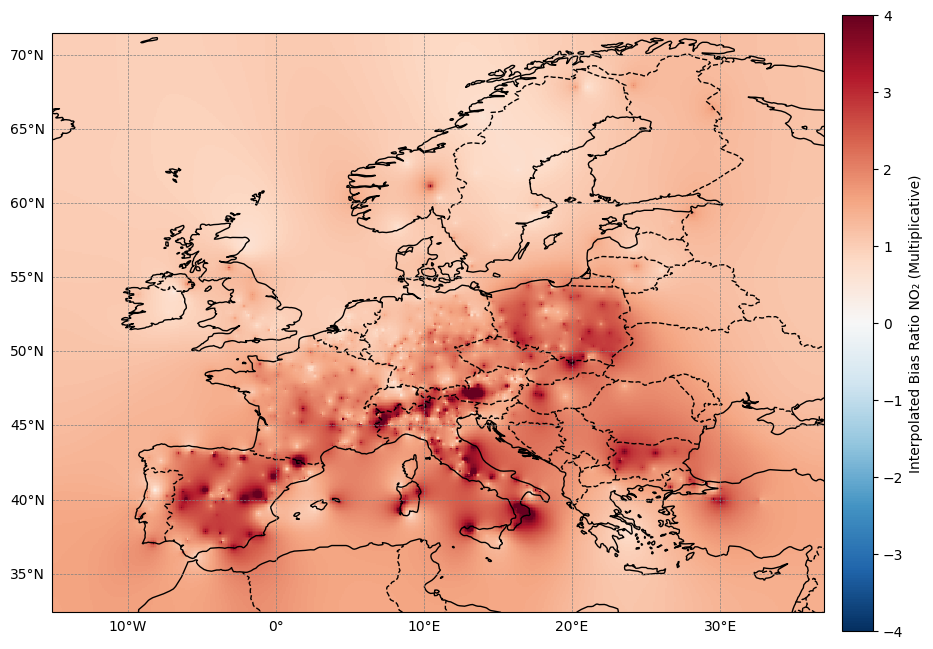

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === Load the Interpolated Bias Ratio NetCDF File for NO₂ ===
bias_netcdf_path = "Bias_Hybrid_Multiplicative.nc"
ds_bias = xr.open_dataset(bias_netcdf_path)

# Extract interpolated bias ratio
interpolated_bias_ratio = ds_bias["Multiplicative_Bias"].squeeze().values

# Extract coordinates
lon = ds_bias["lon"].values
lat = ds_bias["lat"].values

# === Define Plot Limits (Adjust if needed) ===
cbar_min = -4  # Set minimum scale for bias ratio
cbar_max = 4   # Set maximum scale for bias ratio

# Create a plot with Cartopy
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the interpolated bias ratio
im = ax.pcolormesh(lon, lat, interpolated_bias_ratio, transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=cbar_min, vmax=cbar_max, shading='auto')

# Add colorbar
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("Interpolated Bias Ratio NO₂ (Multiplicative)")

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_bias.close()

In [6]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
original_nc_path = "EMEP_yearly_2015.nc"
bias_ratio_nc_path = "Bias_Hybrid_Multiplicative.nc"
corrected_nc_path = "BaseCase_Corrected_NO2_Y_MUL.nc"

# === Load the Original Modeled NO₂ NetCDF ===
with nc.Dataset(original_nc_path, "r") as original_nc, nc.Dataset(bias_ratio_nc_path, "r") as bias_nc:

    # Load model coordinates and data
    lon = original_nc.variables["lon"][:]
    lat = original_nc.variables["lat"][:]
    time = original_nc.variables["time"][:]
    no2_original = original_nc.variables["SURF_ug_NO2"][:]

    # Load the interpolated bias ratio
    interpolated_bias_ratio = bias_nc.variables["Multiplicative_Bias"][:]

    # === Apply Multiplicative Bias Correction ===
    # Ensure bias ratio does not contain values too close to zero
    min_bias_threshold = 0.1  # Prevent extreme scaling
    interpolated_bias_ratio = np.maximum(interpolated_bias_ratio, min_bias_threshold)

    # Correct NO₂
    no2_corrected = no2_original * interpolated_bias_ratio  # Multiplicative correction

    # === Save the Corrected NO₂ to a New NetCDF File ===
    with nc.Dataset(corrected_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        no2_var = new_nc.createVariable("SURF_ug_NO2_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original NO₂ variable
        no2_var.setncatts(original_nc.variables["SURF_ug_NO2"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        no2_var[:] = no2_corrected  # Store corrected NO₂

print("Multiplicative Bias Correction Completed Successfully!")
print("Corrected NO₂ NetCDF file saved as:", corrected_nc_path)

Multiplicative Bias Correction Completed Successfully!
Corrected NO₂ NetCDF file saved as: BaseCase_Corrected_NO2_Y_MUL.nc


In [12]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "BaseCase_Corrected_NO2_Y_MUL.nc"  # Your original file
output_file = "BaseCase_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2015.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_NO2_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_NO2", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: BaseCase_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_NO2']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2', 'NCO': 'netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)'}
JRC File: {'vert

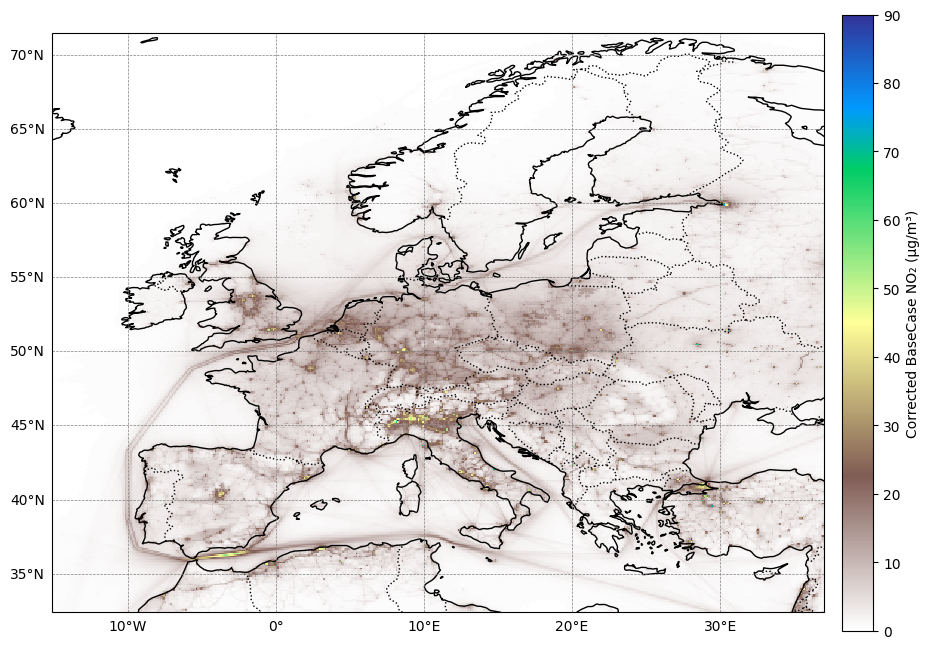

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected NO₂ NetCDF File ===
corrected_netcdf_path = "BaseCase_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected NO₂ values
corrected_no2 = ds_corrected["SURF_ug_NO2"].squeeze().values.T

# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization Scale for NO₂ ===
norm = mcolors.Normalize(0, 90)  # Adjust scale for NO₂ concentration range (µg/m³)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the NO₂ concentration using pcolormesh
mesh = ax.pcolormesh(Lon, Lat, corrected_no2, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected BaseCase NO₂ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

In [16]:

import netCDF4 as nc
import numpy as np

# === Define File Paths ===
scenario_perturbed_nc_path = "EMEP_yearly_2022.nc"  # Perturbed Scenario NetCDF
bias_residual_nc_path = "Bias_Hybrid_Multiplicative.nc"  # Interpolated Bias Ratios NetCDF
corrected_scenario_nc_path = "Scenario_Corrected_NO2_MUL.nc"  # Output Corrected Scenario NetCDF

# === Load NetCDF Files ===
with nc.Dataset(scenario_perturbed_nc_path, "r") as scen_nc, \
     nc.Dataset(bias_residual_nc_path, "r") as bias_nc:

    # Load grid and data
    lon = scen_nc.variables["lon"][:]
    lat = scen_nc.variables["lat"][:]
    time = scen_nc.variables["time"][:]

    no2_scenario_perturbed = scen_nc.variables["SURF_ug_NO2"][:]  # Perturbed Scenario NO₂
    interpolated_bias_ratios = bias_nc.variables["Multiplicative_Bias"][:]  # Interpolated Bias Ratios (OBS / MOD)

    # === Apply Multiplicative Correction ===
    min_ratio_threshold = 0.1  # Optional: prevent extreme downscaling
    interpolated_bias_ratios = np.maximum(interpolated_bias_ratios, min_ratio_threshold)

    no2_scenario_corrected = no2_scenario_perturbed * interpolated_bias_ratios

    # === Save Corrected Scenario ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        no2_var = new_nc.createVariable("SURF_ug_NO2_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the scenario
        no2_var.setncatts(scen_nc.variables["SURF_ug_NO2"].__dict__)

        # Write data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        no2_var[:] = no2_scenario_corrected

print("Multiplicative IDW Bias Correction Applied Successfully!")

Multiplicative IDW Bias Correction Applied Successfully!


In [17]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected_NO2_MUL.nc"  # Your original file
output_file = "Scen_2022_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2022.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_NO2_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_NO2", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])


 Correction completed! Renamed and fixed NetCDF saved as: Scen_2022_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_NO2']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2', 'NCO': 'netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)'}
JRC File: {'ver

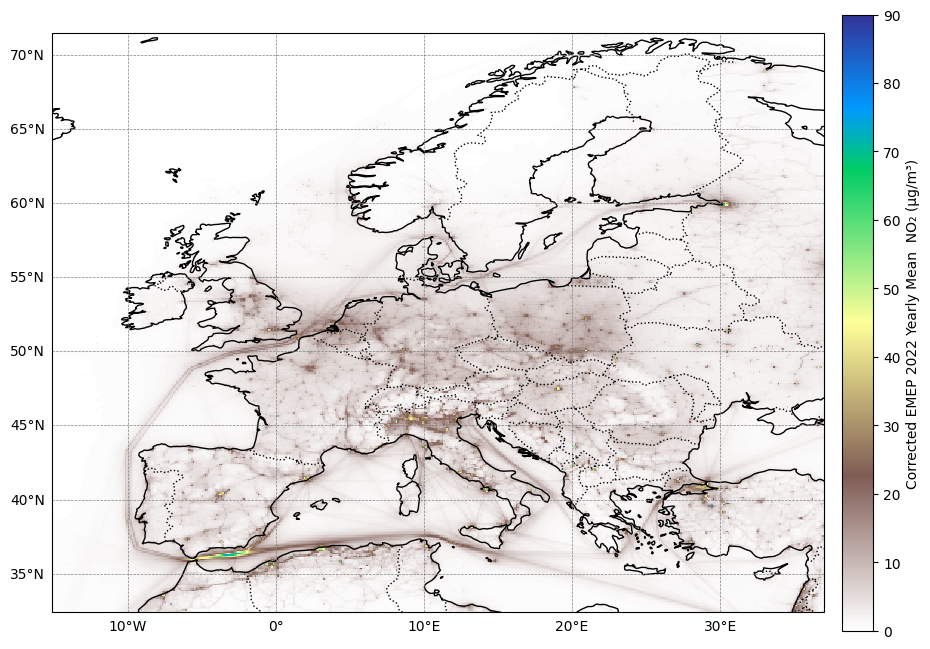

In [18]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected Scenario NO₂ NetCDF File ===
corrected_netcdf_path = "Scen_2022_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc"  # Adjust path if needed
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected NO₂ scenario values
corrected_no2 = ds_corrected["SURF_ug_NO2"].squeeze().values.T

# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization Scale for NO₂ ===
norm = mcolors.Normalize(0, 90)  # Adjust scale for NO₂ concentration range (µg/m³)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the corrected NO₂ scenario using pcolormesh
mesh = ax.pcolormesh(Lon, Lat, corrected_no2, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2022 Yearly Mean  NO₂ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

In [19]:

import netCDF4 as nc
import numpy as np

# === Define File Paths ===
scenario_perturbed_nc_path = "EMEP_yearly_2023.nc"  # Perturbed Scenario NetCDF
bias_residual_nc_path = "Bias_Hybrid_Multiplicative.nc"  # Interpolated Bias Ratios NetCDF
corrected_scenario_nc_path = "Scenario_Corrected3_NO2_MUL.nc"  # Output Corrected Scenario NetCDF

# === Load NetCDF Files ===
with nc.Dataset(scenario_perturbed_nc_path, "r") as scen_nc, \
     nc.Dataset(bias_residual_nc_path, "r") as bias_nc:

    # Load grid and data
    lon = scen_nc.variables["lon"][:]
    lat = scen_nc.variables["lat"][:]
    time = scen_nc.variables["time"][:]

    no2_scenario_perturbed = scen_nc.variables["SURF_ug_NO2"][:]  # Perturbed Scenario NO₂
    interpolated_bias_ratios = bias_nc.variables["Multiplicative_Bias"][:]  # Interpolated Bias Ratios (OBS / MOD)

    # === Apply Multiplicative Correction ===
    min_ratio_threshold = 0.1  # Optional: prevent extreme downscaling
    interpolated_bias_ratios = np.maximum(interpolated_bias_ratios, min_ratio_threshold)

    no2_scenario_corrected = no2_scenario_perturbed * interpolated_bias_ratios

    # === Save Corrected Scenario ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        no2_var = new_nc.createVariable("SURF_ug_NO2_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the scenario
        no2_var.setncatts(scen_nc.variables["SURF_ug_NO2"].__dict__)

        # Write data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        no2_var[:] = no2_scenario_corrected

print("Multiplicative IDW Bias Correction Applied Successfully!")

Multiplicative IDW Bias Correction Applied Successfully!


In [20]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected3_NO2_MUL.nc"  # Your original file
output_file = "Scen_2023_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2023.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_NO2_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_NO2", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])


 Correction completed! Renamed and fixed NetCDF saved as: Scen_2023_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_NO2']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2', 'NCO': 'netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)'}
JRC File: {'ver

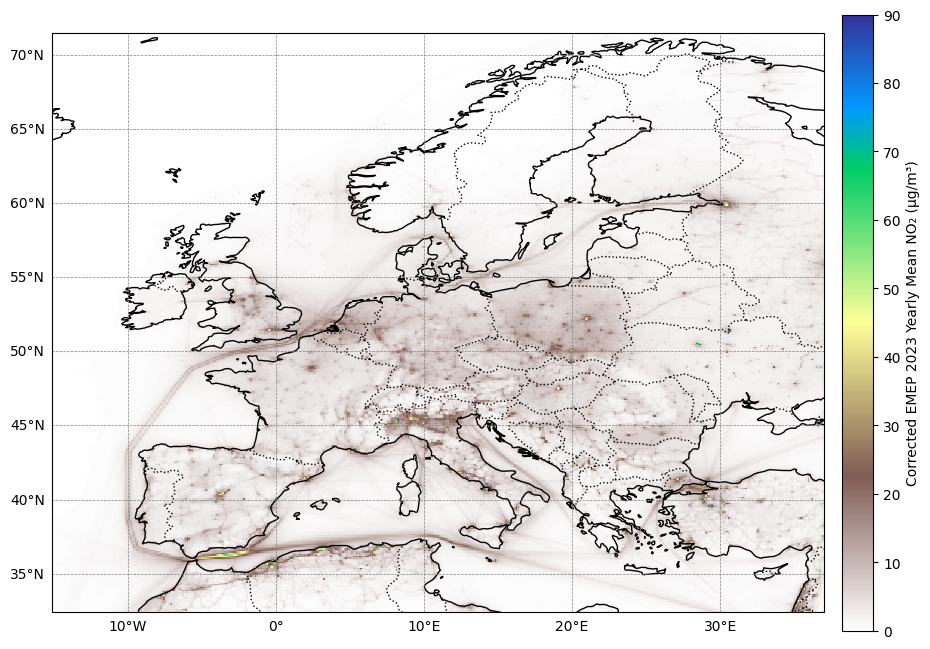

In [21]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected Scenario NO₂ NetCDF File ===
corrected_netcdf_path = "Scen_2023_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc"  # Adjust path if needed
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected NO₂ scenario values
corrected_no2 = ds_corrected["SURF_ug_NO2"].squeeze().values.T

# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization Scale for NO₂ ===
norm = mcolors.Normalize(0, 90)  # Adjust scale for NO₂ concentration range (µg/m³)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the corrected NO₂ scenario using pcolormesh
mesh = ax.pcolormesh(Lon, Lat, corrected_no2, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2023 Yearly Mean NO₂ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

In [24]:

import netCDF4 as nc
import numpy as np

# === Define File Paths ===
scenario_perturbed_nc_path = "EMEP_yearly_2024.nc"  # Perturbed Scenario NetCDF
bias_residual_nc_path = "Bias_Hybrid_Multiplicative.nc"  # Interpolated Bias Ratios NetCDF
corrected_scenario_nc_path = "Scenario_Corrected4_NO2_MUL.nc"  # Output Corrected Scenario NetCDF

# === Load NetCDF Files ===
with nc.Dataset(scenario_perturbed_nc_path, "r") as scen_nc, \
     nc.Dataset(bias_residual_nc_path, "r") as bias_nc:

    # Load grid and data
    lon = scen_nc.variables["lon"][:]
    lat = scen_nc.variables["lat"][:]
    time = scen_nc.variables["time"][:]

    no2_scenario_perturbed = scen_nc.variables["SURF_ug_NO2"][:]  # Perturbed Scenario NO₂
    interpolated_bias_ratios = bias_nc.variables["Multiplicative_Bias"][:]  # Interpolated Bias Ratios (OBS / MOD)

    # === Apply Multiplicative Correction ===
    min_ratio_threshold = 0.1  # Optional: prevent extreme downscaling
    interpolated_bias_ratios = np.maximum(interpolated_bias_ratios, min_ratio_threshold)

    no2_scenario_corrected = no2_scenario_perturbed * interpolated_bias_ratios

    # === Save Corrected Scenario ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        no2_var = new_nc.createVariable("SURF_ug_NO2_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the scenario
        no2_var.setncatts(scen_nc.variables["SURF_ug_NO2"].__dict__)

        # Write data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        no2_var[:] = no2_scenario_corrected

print("Multiplicative IDW Bias Correction Applied Successfully!")

Multiplicative IDW Bias Correction Applied Successfully!


In [25]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected4_NO2_MUL.nc"  # Your original file
output_file = "Scen_2024_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2024.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_NO2_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_NO2", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])


 Correction completed! Renamed and fixed NetCDF saved as: Scen_2024_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_NO2']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2', 'NCO': 'netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)'}
JRC File: {'ver

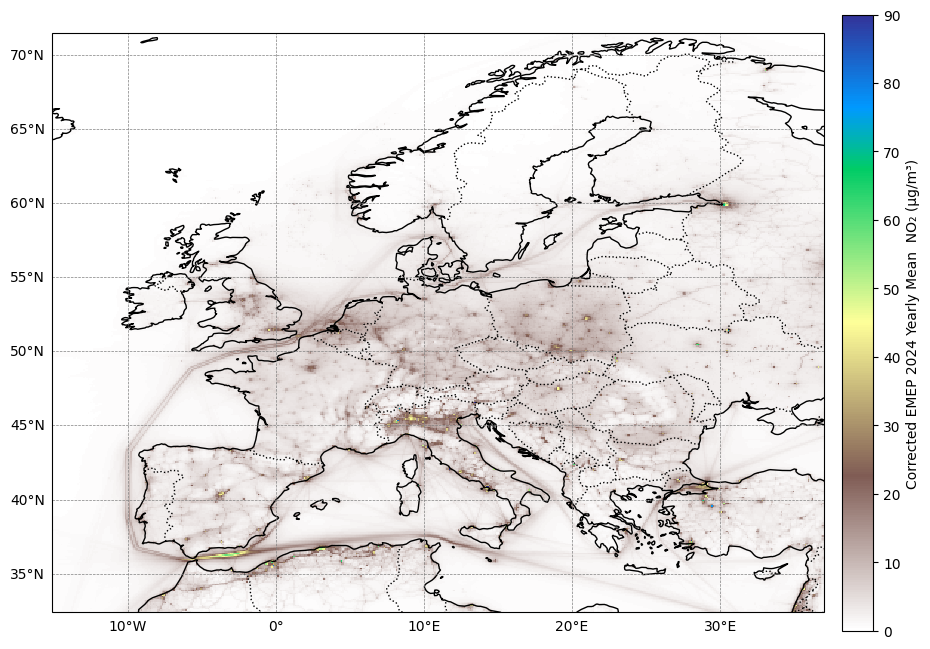

In [26]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected Scenario NO₂ NetCDF File ===
corrected_netcdf_path = "Scen_2024_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc"  # Adjust path if needed
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected NO₂ scenario values
corrected_no2 = ds_corrected["SURF_ug_NO2"].squeeze().values.T

# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization Scale for NO₂ ===
norm = mcolors.Normalize(0, 90)  # Adjust scale for NO₂ concentration range (µg/m³)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the corrected NO₂ scenario using pcolormesh
mesh = ax.pcolormesh(Lon, Lat, corrected_no2, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2024 Yearly Mean  NO₂ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 9.75942406856348
MAE: 7.55685349179529
Bias: -6.317512854057136
R: 0.6809700825471148
R² (corr): 0.4637202533242243
R² (true): -0.01650385720215719

ADI
RMSE: 3.5371681653919045
MAE: 2.184293453806838
Bias: -0.8998372267968884
R: 0.9356338621607707
R² (corr): 0.8754107240218801
R² (true): 0.8664720850823975

===== COUNTRY METRICS =====
   Country   RMSE_Raw   RMSE_WDI   Bias_Raw  Bias_WDI    R2_Raw    R2_WDI    N
5       CY   0.375192   0.028956  -0.375192  0.028956       NaN       NaN    1
11      FI   0.565070   0.083668  -0.562822 -0.083667  1.000000  1.000000    2
30      SI   0.378095   0.176730   0.378095  0.176730       NaN       NaN    1
17      IE   3.154469   0.668496   1.809215 -0.412346  0.830282  0.991801    6
29      SE   3.077791   1.000833  -0.228036 -0.380540  0.767031  0.987910   33
8       DK   2.394992   1.087951  -1.458938 -0.777903  0.745909  0.945071    5
9       EE   2.937448   1.168142  -2

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


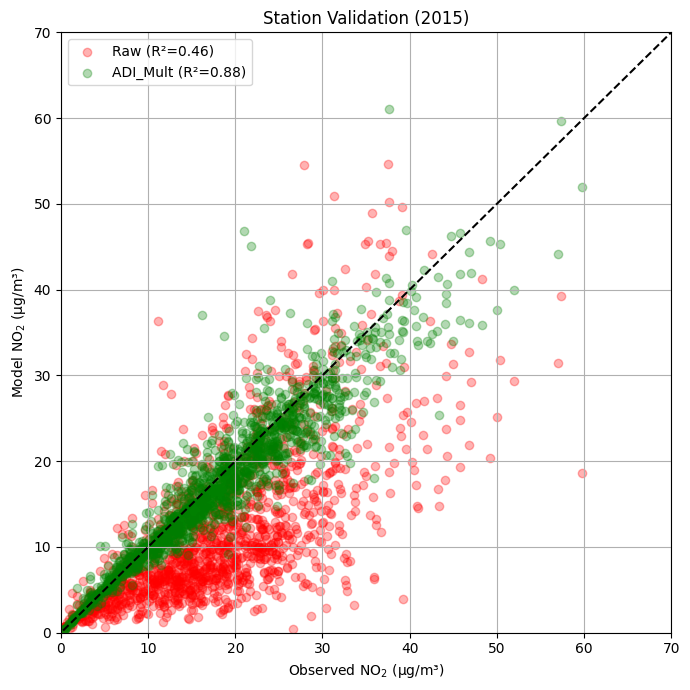

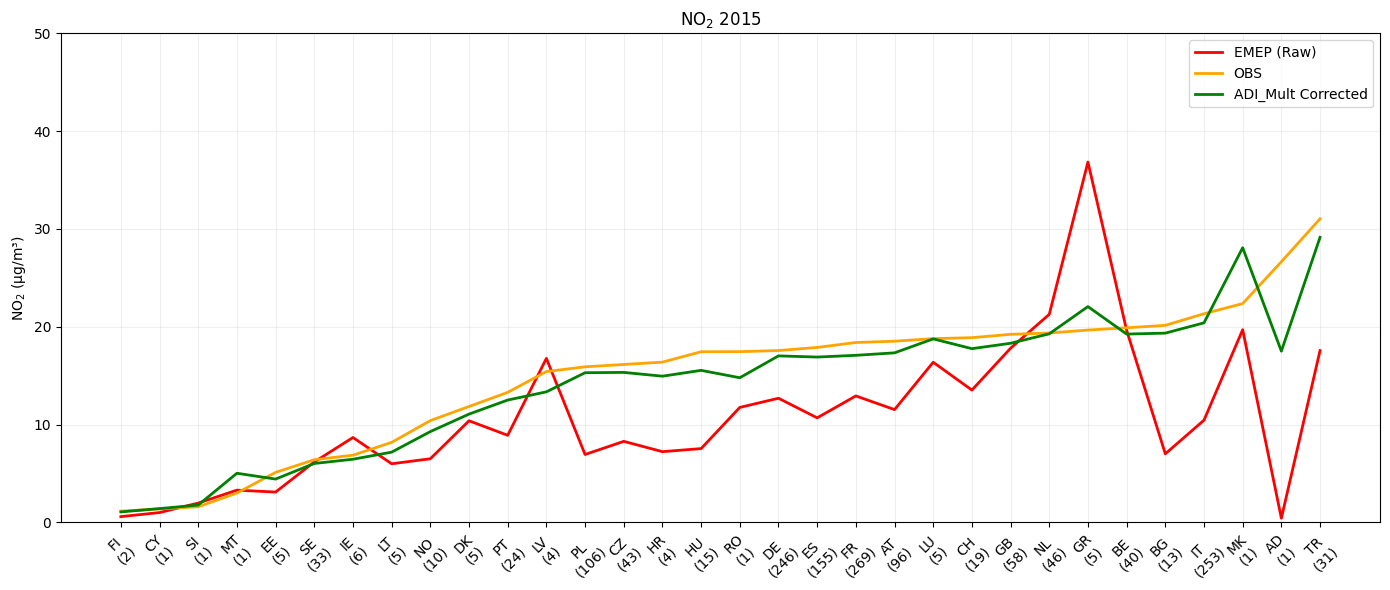

In [33]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2015.nc")
ds_wdi = xr.open_dataset("BaseCase_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_NO2"].values
wdi = ds_wdi["SURF_ug_NO2"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2015.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"ADI_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed NO$_2$ (μg/m³)")
plt.ylabel("Model NO$_2$ (μg/m³)")
plt.title("Station Validation (2015)")
plt.xlim(0,70)
plt.ylim(0,70)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="ADI_Mult Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("NO$_2$ (μg/m³)")
plt.title("NO$_2$ 2015")
plt.ylim(0,50)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 7.865063029200579
MAE: 5.874355408493154
Bias: -4.317399503993686
R: 0.603294093424608
R² (corr): 0.3639637631610197
R² (true): -0.20860050524221063

ADI
RMSE: 4.848813530166167
MAE: 2.9311993956173734
Bias: 0.22884819264395462
R: 0.805810729838925
R² (corr): 0.649330932323541
R² (true): 0.5406440749636945

===== COUNTRY METRICS =====
   Country   RMSE_Raw   RMSE_WDI   Bias_Raw  Bias_WDI    R2_Raw    R2_WDI    N
11      FI   0.416427   0.021949  -0.415480 -0.009511  1.000000  1.000000    2
20      LV   0.646814   0.267791  -0.646814 -0.267791       NaN       NaN    1
22      NO   3.794561   0.407574  -1.755501 -0.143282  0.588497  0.991662    4
9       EE   2.396287   1.114898  -1.475336 -0.329188  0.964776  0.952075    5
25      SE   2.698061   1.274924   0.210909  0.916271  0.681297  0.987208    9
18      LT   3.820113   1.636376  -1.983651 -0.901828  0.504451  0.983402    4
5       CY   2.041407   1.646970  -2.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


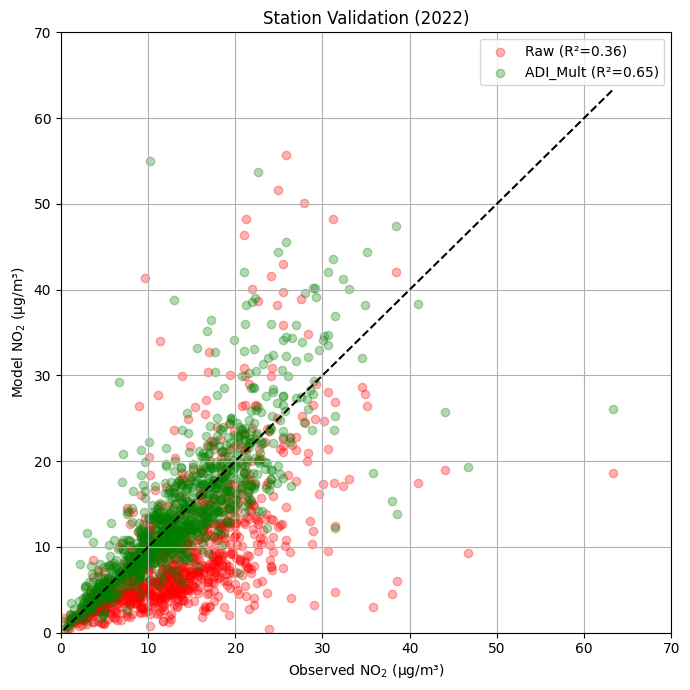

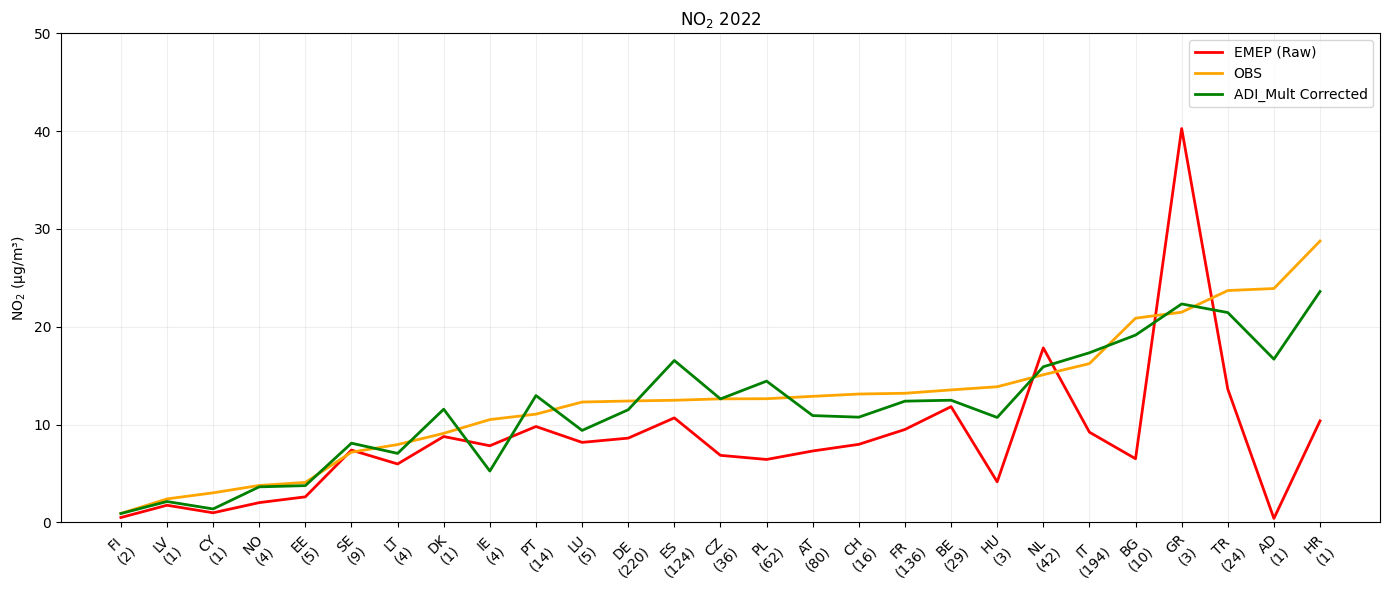

In [35]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2022.nc")
ds_wdi = xr.open_dataset("Scen_2022_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_NO2"].values
wdi = ds_wdi["SURF_ug_NO2"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2022.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"ADI_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed NO$_2$ (μg/m³)")
plt.ylabel("Model NO$_2$ (μg/m³)")
plt.title("Station Validation (2022)")
plt.xlim(0,70)
plt.ylim(0,70)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="ADI_Mult Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("NO$_2$ (μg/m³)")
plt.title("NO$_2$ 2022")
plt.ylim(0,50)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 7.4589150470426935
MAE: 5.4577668143433655
Bias: -3.954253850342293
R: 0.5901335028693347
R² (corr): 0.3482575512088311
R² (true): -0.13753706911082575

ADI
RMSE: 4.928453968087159
MAE: 3.004679148558121
Bias: 0.23364259528371598
R: 0.7807210262699693
R² (corr): 0.6095253208600341
R² (true): 0.5033669181125273

===== COUNTRY METRICS =====
   Country   RMSE_Raw   RMSE_WDI   Bias_Raw  Bias_WDI    R2_Raw    R2_WDI    N
11      FI   0.382246   0.029472  -0.380974  0.025068  1.000000  1.000000    2
20      LV   0.290198   0.066819  -0.290198  0.066819       NaN       NaN    1
9       EE   1.983768   0.787633  -1.274837 -0.092178  0.982728  0.934424    5
5       CY   1.209486   0.816232  -1.209486 -0.816232       NaN       NaN    1
22      NO   4.333295   0.897921  -1.978614 -0.402060  0.599059  0.997196    4
25      SE   2.745489   0.986088   0.152643  0.779171  0.631309  0.991602    9
2       BE   2.341244   1.855072 

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


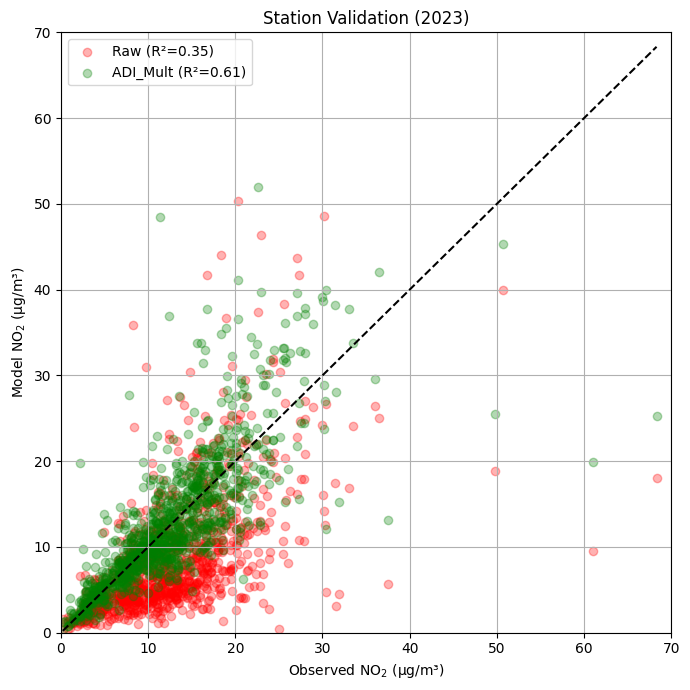

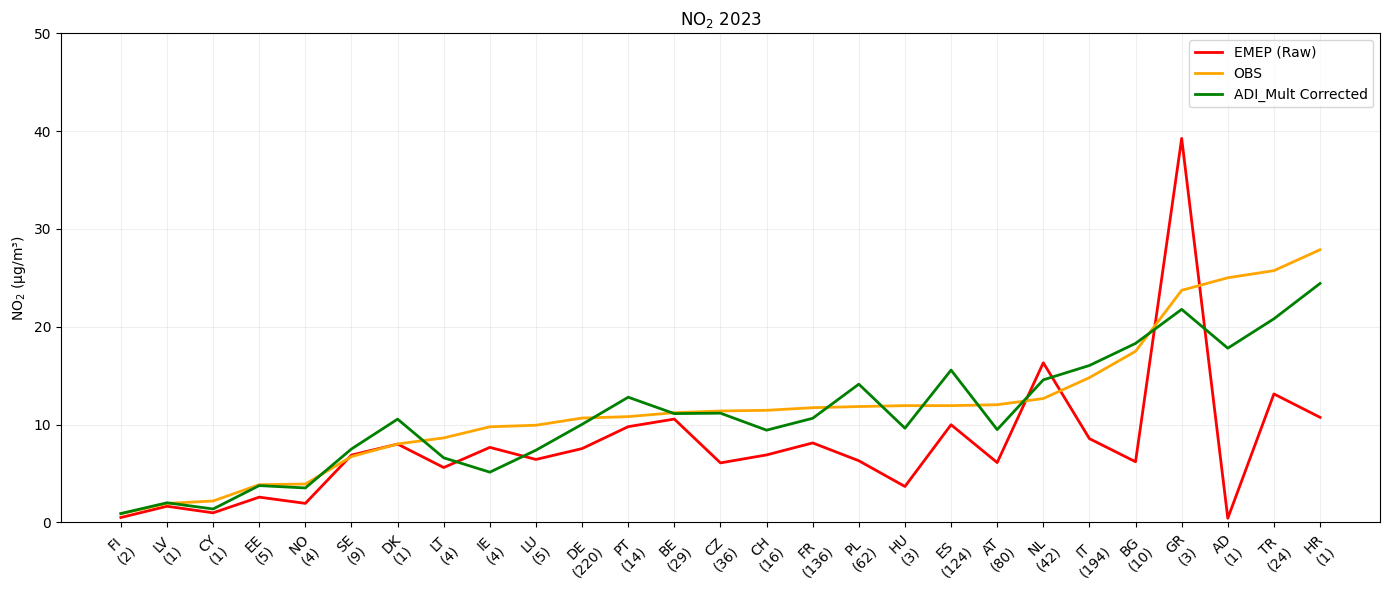

In [36]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2023.nc")
ds_wdi = xr.open_dataset("Scen_2023_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_NO2"].values
wdi = ds_wdi["SURF_ug_NO2"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2023.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"ADI_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed NO$_2$ (μg/m³)")
plt.ylabel("Model NO$_2$ (μg/m³)")
plt.title("Station Validation (2023)")
plt.xlim(0,70)
plt.ylim(0,70)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="ADI_Mult Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("NO$_2$ (μg/m³)")
plt.title("NO$_2$ 2023")
plt.ylim(0,50)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 7.136397355099581
MAE: 5.130538516196875
Bias: -3.239757312425929
R: 0.5871144997213504
R² (corr): 0.3447034357830516
R² (true): -0.09305470018485829

ADI
RMSE: 4.980850049237174
MAE: 3.102673355663753
Bias: 1.0665786122210346
R: 0.7910539317850943
R² (corr): 0.6257663229926567
R² (true): 0.4675353463699815

===== COUNTRY METRICS =====
   Country   RMSE_Raw   RMSE_WDI   Bias_Raw  Bias_WDI    R2_Raw    R2_WDI    N
11      FI   0.241246   0.140930  -0.241217  0.136714  1.000000  1.000000    2
20      LV   0.089624   0.452670   0.089624  0.452670       NaN       NaN    1
22      NO   3.711850   0.678260  -1.469093 -0.124778  0.069720  0.991414    4
5       CY   1.392153   0.990548  -1.392153 -0.990548       NaN       NaN    1
9       EE   2.039707   1.065847  -1.272506 -0.164317  0.995284  0.883662    5
25      SE   2.550559   1.648284   0.718631  1.371168  0.687399  0.993199    9
7       DE   4.456517   1.881588  -2

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


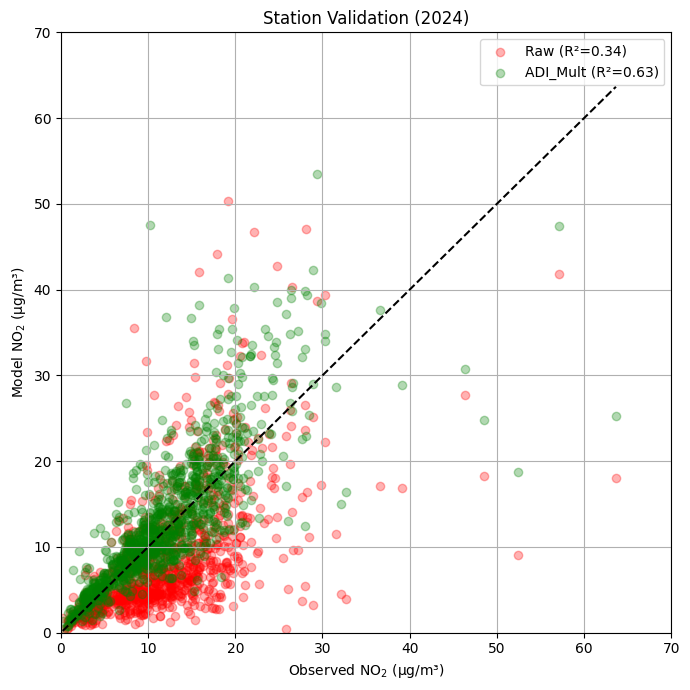

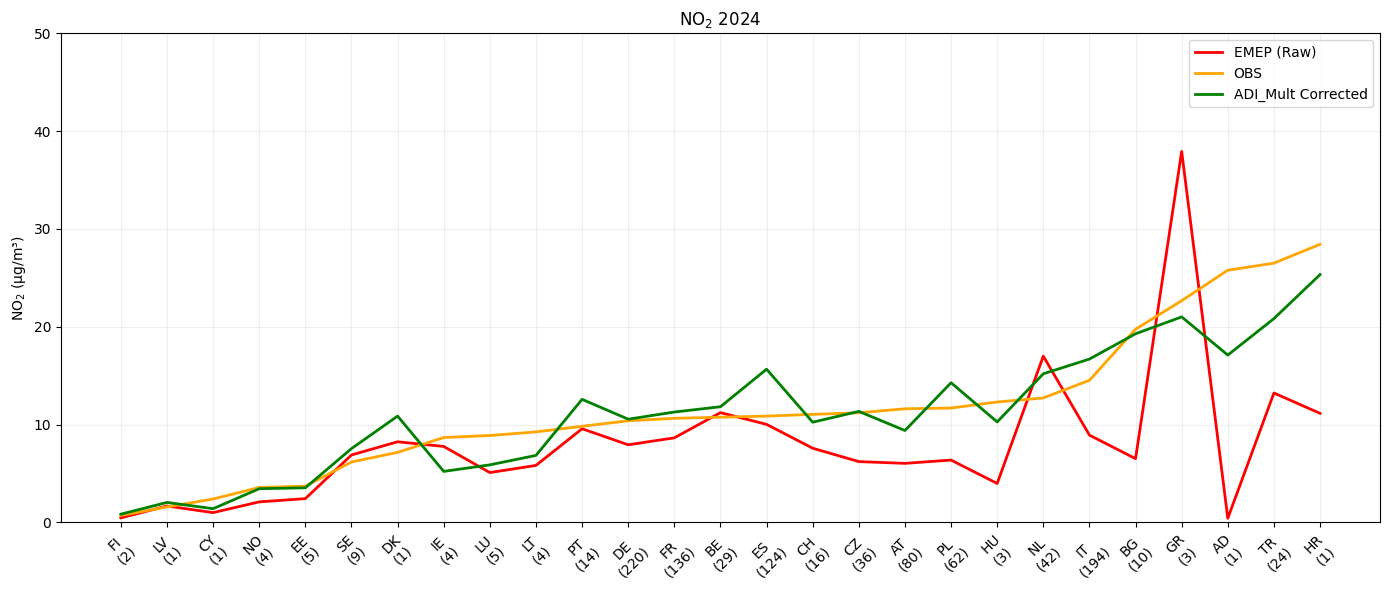

In [37]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2024.nc")
ds_wdi = xr.open_dataset("Scen_2024_NKUA_NO2_CSA.Cell.Mult.ADI_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_NO2"].values
wdi = ds_wdi["SURF_ug_NO2"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2024.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"ADI_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed NO$_2$ (μg/m³)")
plt.ylabel("Model NO$_2$ (μg/m³)")
plt.title("Station Validation (2024)")
plt.xlim(0,70)
plt.ylim(0,70)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="ADI_Mult Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("NO$_2$ (μg/m³)")
plt.title("NO$_2$ 2024")
plt.ylim(0,50)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()